#### Bottom_left

Bin 0: util=0.860  used_vol=15843  cont_vol=18432  size=(24, 24, 32), items=210
Bin 1: util=0.845  used_vol=15568  cont_vol=18432  size=(24, 24, 32), items=211
Bin 2: util=0.849  used_vol=15646  cont_vol=18432  size=(24, 24, 32), items=213
Bin 3: util=0.855  used_vol=15759  cont_vol=18432  size=(24, 24, 32), items=212
Bin 4: util=0.829  used_vol=15277  cont_vol=18432  size=(24, 24, 32), items=212
Bin 5: util=0.843  used_vol=15529  cont_vol=18432  size=(24, 24, 32), items=207
Bin 6: util=0.856  used_vol=15782  cont_vol=18432  size=(24, 24, 32), items=208
Bin 7: util=0.847  used_vol=15614  cont_vol=18432  size=(24, 24, 32), items=216
Bin 8: util=0.834  used_vol=15380  cont_vol=18432  size=(24, 24, 32), items=212
Bin 9: util=0.843  used_vol=15544  cont_vol=18432  size=(24, 24, 32), items=224
Bin 10: util=0.856  used_vol=15775  cont_vol=18432  size=(24, 24, 32), items=220
Bin 11: util=0.846  used_vol=15594  cont_vol=18432  size=(24, 24, 32), items=214
Bin 12: util=0.855  used_vol=15767  co

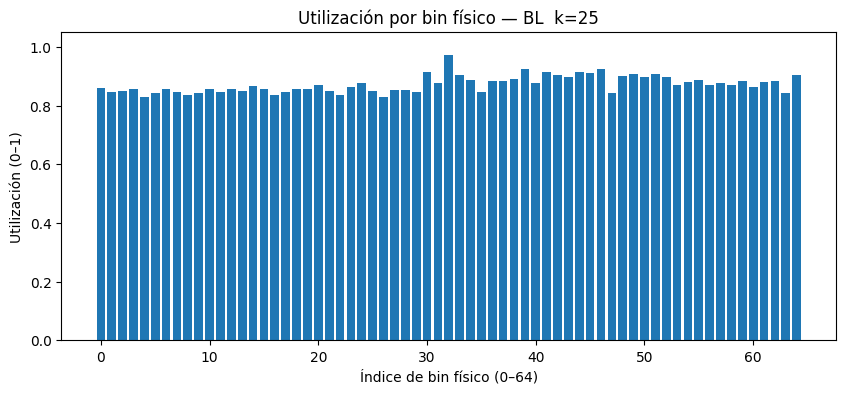


Mostrando Bin 0 con tamaño real (24, 24, 32) y 210 items, util=0.860


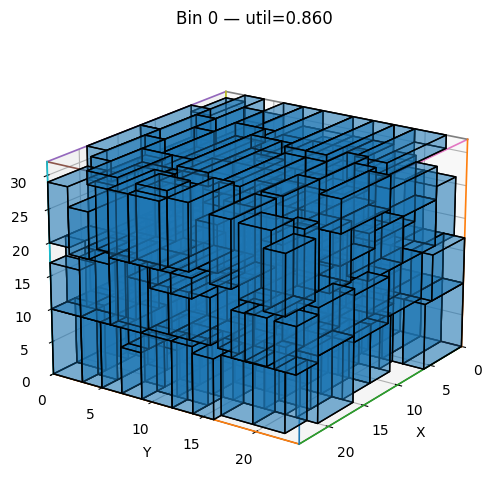

In [1]:
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive\Cloud Sabana\MIT\optimizing_pallet_configuration")

from deeppack3d import deeppack3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'bl'              # heurística bottom-left
K = 25
DATA_MODE = 'file'
PATH = './Input_worst_div10_ceil.txt'

# Un solo episodio (1 corrida completa)
N_ITERS = 1

# ---- Definición de los 65 bins físicos del 747 ----
bin_sizes_real = []
bin_sizes_real += [(24, 24, 32)] * 30   # 30 pallets M1
bin_sizes_real += [(5, 12, 32)] * 23   # 23 slices M1H
bin_sizes_real += [(24, 16, 32)] * 9    # 9 pallets P6P
bin_sizes_real += [(15, 16, 23)] * 2    # 2 LD1
bin_sizes_real += [(20, 20, 17)] * 1    # 1 bulk

NUM_BINS = len(bin_sizes_real)  # 65

# ---- Recolectar colocaciones por bin_id ----
bins = [[] for _ in range(NUM_BINS)]

gen_kwargs = dict(data=DATA_MODE, verbose=0, n_iterations=N_ITERS)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # fin del episodio (vuelo); solo analizamos el primero
        break

    bin_id, (x, y, z), (w, h, d), meta = result

    if 0 <= bin_id < NUM_BINS:
        bins[bin_id].append((x, y, z, w, h, d))
    else:
        print(f"Advertencia: bin_id={bin_id} fuera de rango [0,{NUM_BINS-1}]")

# ---- Cálculo de utilización por bin con tamaño REAL ----
def bin_utilization_real(items, container_size):
    if not items:
        W, H, D = container_size
        container_volume = max(1, W * H * D)
        return 0.0, 0.0, container_volume, container_size

    used_volume = sum(w * h * d for (_, _, _, w, h, d) in items)
    W, H, D = container_size
    container_volume = max(1, W * H * D)
    return used_volume / container_volume, used_volume, container_volume, container_size

utilizations = []
sizes_used = []
used_bins_indices = []

for i, items in enumerate(bins):
    cont_size = bin_sizes_real[i]
    u, used_v, cont_v, sz = bin_utilization_real(items, cont_size)
    utilizations.append(u)
    sizes_used.append(sz)
    if len(items) > 0:
        used_bins_indices.append(i)
        print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}, items={len(items)}")

print(f"\n🧱 Bins físicos con carga: {len(used_bins_indices)} de {NUM_BINS}")

# ---- Gráfico de barras ----
plt.figure(figsize=(10, 4))
plt.bar(range(NUM_BINS), utilizations)
plt.xlabel("Índice de bin físico (0–64)")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin físico — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.05)
plt.show()

# ---- 3D de un bin con carga ----
if used_bins_indices:
    BIN_TO_PLOT = used_bins_indices[0]  # el primero con carga
else:
    BIN_TO_PLOT = 0

items = bins[BIN_TO_PLOT]
(W, H, D) = bin_sizes_real[BIN_TO_PLOT]

print(f"\nMostrando Bin {BIN_TO_PLOT} con tamaño real {W,H,D} y {len(items)} items, util={utilizations[BIN_TO_PLOT]:.3f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    if w <= 0 or h <= 0 or d <= 0:
        return
    X = [x, x + w]; Y = [y, y + h]; Z = [z, z + d]
    faces = [
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[0], Y[1], Z[0])],
        [(X[0], Y[0], Z[1]), (X[1], Y[0], Z[1]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[0], Z[1]), (X[0], Y[0], Z[1])],
        [(X[0], Y[1], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[0], Y[1], Z[0]), (X[0], Y[1], Z[1]), (X[0], Y[0], Z[1])],
        [(X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[1], Y[0], Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def draw_container_wire(ax, W, H, D):
    edges = [
        ((0, 0, 0), (W, 0, 0)), ((W, 0, 0), (W, H, 0)),
        ((W, H, 0), (0, H, 0)), ((0, H, 0), (0, 0, 0)),
        ((0, 0, D), (W, 0, D)), ((W, 0, D), (W, H, D)),
        ((W, H, D), (0, H, D)), ((0, H, D), (0, 0, D)),
        ((0, 0, 0), (0, 0, D)), ((W, 0, 0), (W, 0, D)),
        ((W, H, 0), (W, H, D)), ((0, H, 0), (0, H, D)),
    ]
    for (x1, y1, z1), (x2, y2, z2) in edges:
        ax.plot([x1, x2], [y1, y2], [z1, z2], linewidth=1.2)

draw_container_wire(ax, W, H, D)

for (x, y, z, w, h, d) in items[:300]:
    draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35)

ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_zlim(0, D)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()


##### Gráficar un Bin en especifico


Mostrando Bin 0 con tamaño real (24, 24, 32) y 210 items, util=0.860


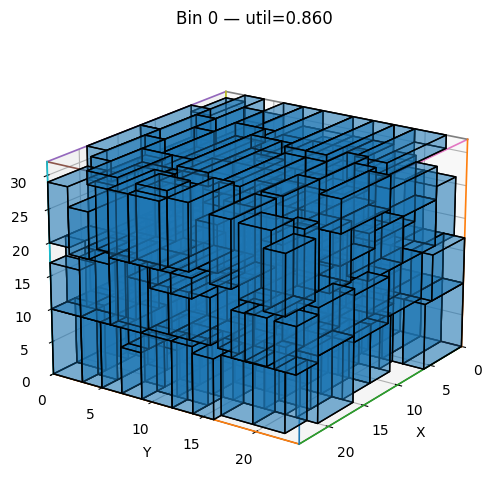

In [9]:
# ---- 3D de un bin con carga ----
if used_bins_indices:
    BIN_TO_PLOT = used_bins_indices[0]  # el primero con carga
else:
    BIN_TO_PLOT = 35

items = bins[BIN_TO_PLOT]
(W, H, D) = bin_sizes_real[BIN_TO_PLOT]

print(f"\nMostrando Bin {BIN_TO_PLOT} con tamaño real {W,H,D} y {len(items)} items, util={utilizations[BIN_TO_PLOT]:.3f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    if w <= 0 or h <= 0 or d <= 0:
        return
    X = [x, x + w]; Y = [y, y + h]; Z = [z, z + d]
    faces = [
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[0], Y[1], Z[0])],
        [(X[0], Y[0], Z[1]), (X[1], Y[0], Z[1]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[0], Z[1]), (X[0], Y[0], Z[1])],
        [(X[0], Y[1], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[0], Y[1], Z[0]), (X[0], Y[1], Z[1]), (X[0], Y[0], Z[1])],
        [(X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[1], Y[0], Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def draw_container_wire(ax, W, H, D):
    edges = [
        ((0, 0, 0), (W, 0, 0)), ((W, 0, 0), (W, H, 0)),
        ((W, H, 0), (0, H, 0)), ((0, H, 0), (0, 0, 0)),
        ((0, 0, D), (W, 0, D)), ((W, 0, D), (W, H, D)),
        ((W, H, D), (0, H, D)), ((0, H, D), (0, 0, D)),
        ((0, 0, 0), (0, 0, D)), ((W, 0, 0), (W, 0, D)),
        ((W, H, 0), (W, H, D)), ((0, H, 0), (0, H, D)),
    ]
    for (x1, y1, z1), (x2, y2, z2) in edges:
        ax.plot([x1, x2], [y1, y2], [z1, z2], linewidth=1.2)

draw_container_wire(ax, W, H, D)

for (x, y, z, w, h, d) in items[:300]:
    draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35)

ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_zlim(0, D)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()

##### Total de cajas empacadas por bin y en todo el avión

In [3]:
from collections import Counter

total_packed = 0

for i, items in enumerate(bins):
    n = len(items)
    total_packed += n
    print(f"Bin {i:2d}: {n:4d} cajas")

print("\n📦 Cajas empacadas en todo el avión:", total_packed)


Bin  0:  210 cajas
Bin  1:  211 cajas
Bin  2:  213 cajas
Bin  3:  212 cajas
Bin  4:  212 cajas
Bin  5:  207 cajas
Bin  6:  208 cajas
Bin  7:  216 cajas
Bin  8:  212 cajas
Bin  9:  224 cajas
Bin 10:  220 cajas
Bin 11:  214 cajas
Bin 12:  213 cajas
Bin 13:  224 cajas
Bin 14:  207 cajas
Bin 15:  223 cajas
Bin 16:  205 cajas
Bin 17:  212 cajas
Bin 18:  214 cajas
Bin 19:  219 cajas
Bin 20:  216 cajas
Bin 21:  218 cajas
Bin 22:  208 cajas
Bin 23:  228 cajas
Bin 24:  233 cajas
Bin 25:  213 cajas
Bin 26:  202 cajas
Bin 27:  212 cajas
Bin 28:  218 cajas
Bin 29:  214 cajas
Bin 30:   26 cajas
Bin 31:   22 cajas
Bin 32:   26 cajas
Bin 33:   24 cajas
Bin 34:   25 cajas
Bin 35:   23 cajas
Bin 36:   26 cajas
Bin 37:   25 cajas
Bin 38:   27 cajas
Bin 39:   27 cajas
Bin 40:   24 cajas
Bin 41:   26 cajas
Bin 42:   27 cajas
Bin 43:   23 cajas
Bin 44:   26 cajas
Bin 45:   27 cajas
Bin 46:   27 cajas
Bin 47:   24 cajas
Bin 48:   29 cajas
Bin 49:   26 cajas
Bin 50:   27 cajas
Bin 51:   27 cajas
Bin 52:   24

##### Ver qué tamaños de cajas se empacaron en cada bin

In [5]:
from collections import Counter

for i, items in enumerate(bins):
    if not items:
        continue
    # contamos por tamaño (w,h,d)
    size_counts = Counter((w, h, d) for (_,_,_, w, h, d) in items)
    print(f"\nBin {i} — {len(items)} cajas")
    for (w, h, d), cnt in size_counts.most_common():
        print(f"  {cnt:4d}  cajas de tamaño ({w},{h},{d})")



Bin 0 — 210 cajas
    48  cajas de tamaño (5,2,7)
    23  cajas de tamaño (3,3,9)
    22  cajas de tamaño (6,2,10)
    21  cajas de tamaño (3,2,10)
    18  cajas de tamaño (5,2,10)
    13  cajas de tamaño (7,2,5)
    10  cajas de tamaño (3,3,10)
     7  cajas de tamaño (3,2,7)
     7  cajas de tamaño (4,2,9)
     4  cajas de tamaño (7,2,3)
     4  cajas de tamaño (2,2,10)
     4  cajas de tamaño (2,3,9)
     4  cajas de tamaño (7,3,2)
     4  cajas de tamaño (3,3,11)
     3  cajas de tamaño (3,1,10)
     3  cajas de tamaño (2,3,10)
     2  cajas de tamaño (10,3,2)
     2  cajas de tamaño (9,3,3)
     2  cajas de tamaño (4,2,10)
     2  cajas de tamaño (1,3,10)
     2  cajas de tamaño (10,2,3)
     1  cajas de tamaño (5,2,9)
     1  cajas de tamaño (2,3,7)
     1  cajas de tamaño (9,2,4)
     1  cajas de tamaño (3,2,9)
     1  cajas de tamaño (9,3,2)

Bin 1 — 211 cajas
    72  cajas de tamaño (5,2,7)
    28  cajas de tamaño (3,3,9)
    15  cajas de tamaño (5,2,10)
    11  cajas de tama

##### Ver el listado de cajas en un bin concreto (por ejemplo Bin 0)

In [6]:
BIN_DE_EJEMPLO = 0

print(f"Bin {BIN_DE_EJEMPLO} — {len(bins[BIN_DE_EJEMPLO])} cajas:")
for (x, y, z, w, h, d) in bins[BIN_DE_EJEMPLO][:20]:  # primeras 20 para no explotar la consola
    print(f"  pos=({x:2d},{y:2d},{z:2d})  tam=({w},{h},{d})")


Bin 0 — 210 cajas:
  pos=( 0, 0, 0)  tam=(3,1,10)
  pos=( 0, 0,10)  tam=(3,2,7)
  pos=( 0, 0,17)  tam=(5,2,7)
  pos=( 0, 0,24)  tam=(5,2,7)
  pos=( 3, 0, 0)  tam=(3,2,10)
  pos=( 3, 0,10)  tam=(3,2,7)
  pos=( 5, 0,17)  tam=(3,1,10)
  pos=( 6, 0, 0)  tam=(6,2,10)
  pos=( 6, 0,10)  tam=(5,2,7)
  pos=( 5, 0,27)  tam=(7,2,5)
  pos=( 8, 0,17)  tam=(5,2,10)
  pos=(12, 0, 0)  tam=(6,2,10)
  pos=(11, 0,10)  tam=(5,2,7)
  pos=(13, 0,17)  tam=(6,2,10)
  pos=(12, 0,27)  tam=(7,2,5)
  pos=(16, 0,10)  tam=(3,2,7)
  pos=(18, 0, 0)  tam=(3,3,10)
  pos=(19, 0,10)  tam=(3,2,10)
  pos=(19, 0,20)  tam=(5,2,9)
  pos=(21, 0, 0)  tam=(3,3,10)


##### ¿Y cuántas cajas había en total (empacadas + no empacadas)?

In [8]:
import numpy as np

all_items = np.loadtxt(PATH, dtype=int)   # si los datos están "w h d" por línea
total_items_file = all_items.shape[0]

print("Total de cajas en el archivo:", total_items_file)

no_empacadas = total_items_file - total_packed
print("Cajas NO empacadas:", no_empacadas)


Total de cajas en el archivo: 10911
Cajas NO empacadas: 2340


#### Best_short_side_fit

In [ ]:
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main - 2 - testing")

from deeppack3d import deeppack3d
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'baf'              # <--- CAMBIADO: antes era 'rl'
K = 90
DATA_MODE = 'file'         # usamos tu archivo de datos
PATH = './Input_worst_div10_ceil.txt'       # asegúrate de que este archivo exista ahí
N_ITERS = 200              # solo se usa si DATA_MODE == 'generated'
SEED = 42                  # solo se usa si DATA_MODE == 'generated'

# (Opcional) tamaño del contenedor/pallet (W,H,D)
CONTAINER_SIZE = None      # None => se infiere por bounding box

# ---- Recolectar colocaciones por bin ----
bins = []               # lista de bins; cada bin es una lista de items
current_bin_items = None

gen_kwargs = dict(data=DATA_MODE, verbose=0)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH
else:
    gen_kwargs['n_iterations'] = N_ITERS
    gen_kwargs['seed'] = SEED

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # empieza un nuevo bin
        current_bin_items = []
        bins.append(current_bin_items)
        continue
    bin_id, (x,y,z), (w,h,d), meta = result
    if current_bin_items is None:
        current_bin_items = []
        bins.append(current_bin_items)
    current_bin_items.append((x,y,z,w,h,d))

num_bins = len(bins)
print(f"🧱 Bins detectados: {num_bins}")

# ---- Utilidad por bin ----
def bin_utilization(items, container_size=None):
    """Devuelve (utilizacion, used_volume, container_volume, (W,H,D) usado)"""
    if not items:
        return 0.0, 0.0, 0.0, (0,0,0)
    used_volume = sum(w*h*d for (_,_,_,w,h,d) in items)
    if container_size is None:
        # inferir por bounding box de lo empacado
        max_x = max(x+w for (x,y,z,w,h,d) in items)
        max_y = max(y+h for (x,y,z,w,h,d) in items)
        max_z = max(z+d for (x,y,z,w,h,d) in items)
        W,H,D = max_x, max_y, max_z
    else:
        W,H,D = container_size
    container_volume = max(1, W*H*D)  # evita div/0
    return (used_volume / container_volume, used_volume, container_volume, (W,H,D))

utilizations = []
sizes_used = []
for i, items in enumerate(bins):
    u, used_v, cont_v, sz = bin_utilization(items, CONTAINER_SIZE)
    utilizations.append(u)
    sizes_used.append(sz)
    print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}")

# ---- Gráfico de barras: utilización por bin ----
plt.figure(figsize=(8,4))
plt.bar(range(len(utilizations)), utilizations)
plt.xlabel("Bin")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.0)
plt.show()

# ---- 3D del bin que elijas ----
BIN_TO_PLOT = 40  # cambia el índice para ver otro bin

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    # Si por algún error vino una caja "vacía", no la dibujes
    if w <= 0 or h <= 0 or d <= 0:
        return

    X = [x, x+w]; Y = [y, y+h]; Z = [z, z+d]
    faces = [
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[0],Y[1],Z[0])],
        [(X[0],Y[0],Z[1]), (X[1],Y[0],Z[1]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[0],Z[1]), (X[0],Y[0],Z[1])],
        [(X[0],Y[1],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[0],Y[1],Z[0]), (X[0],Y[1],Z[1]), (X[0],Y[0],Z[1])],
        [(X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[1],Y[0],Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def get_axis_limits(items, fallback=(1,1,1)):
    if not items:
        return (0,1),(0,1),(0,1)
    max_x = max(x+w for (x,y,z,w,h,d) in items)
    max_y = max(y+h for (x,y,z,w,h,d) in items)
    max_z = max(z+d for (x,y,z,w,h,d) in items)
    return (0, max(max_x, fallback[0])), (0, max(max_y, fallback[1])), (0, max(max_z, fallback[2]))

items = bins[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else []
(W,H,D) = sizes_used[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else (1,1,1)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# dibuja contenedor solo con líneas (sin Poly3DCollection para evitar el bug)
def draw_container_wire(ax, W,H,D):
    edges = [
        ((0,0,0),(W,0,0)), ((W,0,0),(W,H,0)),
        ((W,H,0),(0,H,0)), ((0,H,0),(0,0,0)),
        ((0,0,D),(W,0,D)), ((W,0,D),(W,H,D)),
        ((W,H,D),(0,H,D)), ((0,H,D),(0,0,D)),
        ((0,0,0),(0,0,D)), ((W,0,0),(W,0,D)),
        ((W,H,0),(W,H,D)), ((0,H,0),(0,H,D)),
    ]
    for (x1,y1,z1),(x2,y2,z2) in edges:
        ax.plot([x1,x2],[y1,y2],[z1,z2], linewidth=1.2)

# dibuja contenedor inferido o indicado
draw_container_wire(ax, W,H,D)

# dibuja cajas (limita cantidad si hay muchas)
for (x,y,z,w,h,d) in items[:300]:
    draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35)

# ejes
(xmin,xmax),(ymin,ymax),(zmin,zmax) = get_axis_limits(items, (W,H,D))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_zlim(zmin, zmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()


In [ ]:
#### Bottom_left
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive\Cloud Sabana\MIT\optimizing_pallet_configuration")

from deeppack3d import deeppack3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'baf'              # heurística bottom-left
K = 50
DATA_MODE = 'file'
PATH = './Input_worst_div10_ceil.txt'

# Un solo episodio (1 corrida completa)
N_ITERS = 1

# ---- Definición de los 65 bins físicos del 747 ----
bin_sizes_real = []
bin_sizes_real += [(24, 24, 32)] * 30   # 30 pallets M1
bin_sizes_real += [(5, 12, 32)] * 23   # 23 slices M1H
bin_sizes_real += [(24, 16, 32)] * 9    # 9 pallets P6P
bin_sizes_real += [(15, 16, 23)] * 2    # 2 LD1
bin_sizes_real += [(20, 20, 17)] * 1    # 1 bulk

NUM_BINS = len(bin_sizes_real)  # 65

# ---- Recolectar colocaciones por bin_id ----
bins = [[] for _ in range(NUM_BINS)]

gen_kwargs = dict(data=DATA_MODE, verbose=0, n_iterations=N_ITERS)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # fin del episodio (vuelo); solo analizamos el primero
        break

    bin_id, (x, y, z), (w, h, d), meta = result

    if 0 <= bin_id < NUM_BINS:
        bins[bin_id].append((x, y, z, w, h, d))
    else:
        print(f"Advertencia: bin_id={bin_id} fuera de rango [0,{NUM_BINS-1}]")

# ---- Cálculo de utilización por bin con tamaño REAL ----
def bin_utilization_real(items, container_size):
    if not items:
        W, H, D = container_size
        container_volume = max(1, W * H * D)
        return 0.0, 0.0, container_volume, container_size

    used_volume = sum(w * h * d for (_, _, _, w, h, d) in items)
    W, H, D = container_size
    container_volume = max(1, W * H * D)
    return used_volume / container_volume, used_volume, container_volume, container_size

utilizations = []
sizes_used = []
used_bins_indices = []

for i, items in enumerate(bins):
    cont_size = bin_sizes_real[i]
    u, used_v, cont_v, sz = bin_utilization_real(items, cont_size)
    utilizations.append(u)
    sizes_used.append(sz)
    if len(items) > 0:
        used_bins_indices.append(i)
        print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}, items={len(items)}")

print(f"\n🧱 Bins físicos con carga: {len(used_bins_indices)} de {NUM_BINS}")

# ---- Gráfico de barras ----
plt.figure(figsize=(10, 4))
plt.bar(range(NUM_BINS), utilizations)
plt.xlabel("Índice de bin físico (0–64)")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin físico — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.05)
plt.show()

# ---- 3D de un bin con carga ----
if used_bins_indices:
    BIN_TO_PLOT = used_bins_indices[0]  # el primero con carga
else:
    BIN_TO_PLOT = 0

items = bins[BIN_TO_PLOT]
(W, H, D) = bin_sizes_real[BIN_TO_PLOT]

print(f"\nMostrando Bin {BIN_TO_PLOT} con tamaño real {W,H,D} y {len(items)} items, util={utilizations[BIN_TO_PLOT]:.3f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    if w <= 0 or h <= 0 or d <= 0:
        return
    X = [x, x + w]; Y = [y, y + h]; Z = [z, z + d]
    faces = [
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[0], Y[1], Z[0])],
        [(X[0], Y[0], Z[1]), (X[1], Y[0], Z[1]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[0], Z[1]), (X[0], Y[0], Z[1])],
        [(X[0], Y[1], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[0], Y[1], Z[0]), (X[0], Y[1], Z[1]), (X[0], Y[0], Z[1])],
        [(X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[1], Y[0], Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def draw_container_wire(ax, W, H, D):
    edges = [
        ((0, 0, 0), (W, 0, 0)), ((W, 0, 0), (W, H, 0)),
        ((W, H, 0), (0, H, 0)), ((0, H, 0), (0, 0, 0)),
        ((0, 0, D), (W, 0, D)), ((W, 0, D), (W, H, D)),
        ((W, H, D), (0, H, D)), ((0, H, D), (0, 0, D)),
        ((0, 0, 0), (0, 0, D)), ((W, 0, 0), (W, 0, D)),
        ((W, H, 0), (W, H, D)), ((0, H, 0), (0, H, D)),
    ]
    for (x1, y1, z1), (x2, y2, z2) in edges:
        ax.plot([x1, x2], [y1, y2], [z1, z2], linewidth=1.2)

draw_container_wire(ax, W, H, D)

for (x, y, z, w, h, d) in items[:300]:
    draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35)

ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_zlim(0, D)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()

##### Gráficar un Bin en especifico
# ---- 3D de un bin con carga ----
if used_bins_indices:
    BIN_TO_PLOT = used_bins_indices[0]  # el primero con carga
else:
    BIN_TO_PLOT = 20

items = bins[BIN_TO_PLOT]
(W, H, D) = bin_sizes_real[BIN_TO_PLOT]

print(f"\nMostrando Bin {BIN_TO_PLOT} con tamaño real {W,H,D} y {len(items)} items, util={utilizations[BIN_TO_PLOT]:.3f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    if w <= 0 or h <= 0 or d <= 0:
        return
    X = [x, x + w]; Y = [y, y + h]; Z = [z, z + d]
    faces = [
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[0], Y[1], Z[0])],
        [(X[0], Y[0], Z[1]), (X[1], Y[0], Z[1]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[0], Z[1]), (X[0], Y[0], Z[1])],
        [(X[0], Y[1], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[0], Y[1], Z[0]), (X[0], Y[1], Z[1]), (X[0], Y[0], Z[1])],
        [(X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[1], Y[0], Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def draw_container_wire(ax, W, H, D):
    edges = [
        ((0, 0, 0), (W, 0, 0)), ((W, 0, 0), (W, H, 0)),
        ((W, H, 0), (0, H, 0)), ((0, H, 0), (0, 0, 0)),
        ((0, 0, D), (W, 0, D)), ((W, 0, D), (W, H, D)),
        ((W, H, D), (0, H, D)), ((0, H, D), (0, 0, D)),
        ((0, 0, 0), (0, 0, D)), ((W, 0, 0), (W, 0, D)),
        ((W, H, 0), (W, H, D)), ((0, H, 0), (0, H, D)),
    ]
    for (x1, y1, z1), (x2, y2, z2) in edges:
        ax.plot([x1, x2], [y1, y2], [z1, z2], linewidth=1.2)

draw_container_wire(ax, W, H, D)

for (x, y, z, w, h, d) in items[:300]:
    draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35)

ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_zlim(0, D)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()
##### Total de cajas empacadas por bin y en todo el avión
from collections import Counter

total_packed = 0

for i, items in enumerate(bins):
    n = len(items)
    total_packed += n
    print(f"Bin {i:2d}: {n:4d} cajas")

print("\n📦 Cajas empacadas en todo el avión:", total_packed)

##### Ver qué tamaños de cajas se empacaron en cada bin
from collections import Counter

for i, items in enumerate(bins):
    if not items:
        continue
    # contamos por tamaño (w,h,d)
    size_counts = Counter((w, h, d) for (_,_,_, w, h, d) in items)
    print(f"\nBin {i} — {len(items)} cajas")
    for (w, h, d), cnt in size_counts.most_common():
        print(f"  {cnt:4d}  cajas de tamaño ({w},{h},{d})")

##### Ver el listado de cajas en un bin concreto (por ejemplo Bin 0)
BIN_DE_EJEMPLO = 0

print(f"Bin {BIN_DE_EJEMPLO} — {len(bins[BIN_DE_EJEMPLO])} cajas:")
for (x, y, z, w, h, d) in bins[BIN_DE_EJEMPLO][:20]:  # primeras 20 para no explotar la consola
    print(f"  pos=({x:2d},{y:2d},{z:2d})  tam=({w},{h},{d})")

##### ¿Y cuántas cajas había en total (empacadas + no empacadas)?
import numpy as np

all_items = np.loadtxt(PATH, dtype=int)   # si los datos están "w h d" por línea
total_items_file = all_items.shape[0]

print("Total de cajas en el archivo:", total_items_file)

no_empacadas = total_items_file - total_packed
print("Cajas NO empacadas:", no_empacadas)


#### Best_area_fit

In [ ]:
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main - 2 - testing")

from deeppack3d import deeppack3d
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'bssf'              # <--- CAMBIADO: antes era 'rl'
K = 90
DATA_MODE = 'file'         # usamos tu archivo de datos
PATH = './Input_worst_div10_ceil.txt'       # asegúrate de que este archivo exista ahí
N_ITERS = 200              # solo se usa si DATA_MODE == 'generated'
SEED = 42                  # solo se usa si DATA_MODE == 'generated'

# (Opcional) tamaño del contenedor/pallet (W,H,D)
CONTAINER_SIZE = None      # None => se infiere por bounding box

# ---- Recolectar colocaciones por bin ----
bins = []               # lista de bins; cada bin es una lista de items
current_bin_items = None

gen_kwargs = dict(data=DATA_MODE, verbose=0)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH
else:
    gen_kwargs['n_iterations'] = N_ITERS
    gen_kwargs['seed'] = SEED

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # empieza un nuevo bin
        current_bin_items = []
        bins.append(current_bin_items)
        continue
    bin_id, (x,y,z), (w,h,d), meta = result
    if current_bin_items is None:
        current_bin_items = []
        bins.append(current_bin_items)
    current_bin_items.append((x,y,z,w,h,d))

num_bins = len(bins)
print(f"🧱 Bins detectados: {num_bins}")

# ---- Utilidad por bin ----
def bin_utilization(items, container_size=None):
    """Devuelve (utilizacion, used_volume, container_volume, (W,H,D) usado)"""
    if not items:
        return 0.0, 0.0, 0.0, (0,0,0)
    used_volume = sum(w*h*d for (_,_,_,w,h,d) in items)
    if container_size is None:
        # inferir por bounding box de lo empacado
        max_x = max(x+w for (x,y,z,w,h,d) in items)
        max_y = max(y+h for (x,y,z,w,h,d) in items)
        max_z = max(z+d for (x,y,z,w,h,d) in items)
        W,H,D = max_x, max_y, max_z
    else:
        W,H,D = container_size
    container_volume = max(1, W*H*D)  # evita div/0
    return (used_volume / container_volume, used_volume, container_volume, (W,H,D))

utilizations = []
sizes_used = []
for i, items in enumerate(bins):
    u, used_v, cont_v, sz = bin_utilization(items, CONTAINER_SIZE)
    utilizations.append(u)
    sizes_used.append(sz)
    print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}")

# ---- Gráfico de barras: utilización por bin ----
plt.figure(figsize=(8,4))
plt.bar(range(len(utilizations)), utilizations)
plt.xlabel("Bin")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.0)
plt.show()

# ---- 3D del bin que elijas ----
BIN_TO_PLOT = 40  # cambia el índice para ver otro bin

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    # Si por algún error vino una caja "vacía", no la dibujes
    if w <= 0 or h <= 0 or d <= 0:
        return

    X = [x, x+w]; Y = [y, y+h]; Z = [z, z+d]
    faces = [
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[0],Y[1],Z[0])],
        [(X[0],Y[0],Z[1]), (X[1],Y[0],Z[1]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[0],Z[1]), (X[0],Y[0],Z[1])],
        [(X[0],Y[1],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[0],Y[1],Z[0]), (X[0],Y[1],Z[1]), (X[0],Y[0],Z[1])],
        [(X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[1],Y[0],Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def get_axis_limits(items, fallback=(1,1,1)):
    if not items:
        return (0,1),(0,1),(0,1)
    max_x = max(x+w for (x,y,z,w,h,d) in items)
    max_y = max(y+h for (x,y,z,w,h,d) in items)
    max_z = max(z+d for (x,y,z,w,h,d) in items)
    return (0, max(max_x, fallback[0])), (0, max(max_y, fallback[1])), (0, max(max_z, fallback[2]))

items = bins[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else []
(W,H,D) = sizes_used[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else (1,1,1)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# dibuja contenedor solo con líneas (sin Poly3DCollection para evitar el bug)
def draw_container_wire(ax, W,H,D):
    edges = [
        ((0,0,0),(W,0,0)), ((W,0,0),(W,H,0)),
        ((W,H,0),(0,H,0)), ((0,H,0),(0,0,0)),
        ((0,0,D),(W,0,D)), ((W,0,D),(W,H,D)),
        ((W,H,D),(0,H,D)), ((0,H,D),(0,0,D)),
        ((0,0,0),(0,0,D)), ((W,0,0),(W,0,D)),
        ((W,H,0),(W,H,D)), ((0,H,0),(0,H,D)),
    ]
    for (x1,y1,z1),(x2,y2,z2) in edges:
        ax.plot([x1,x2],[y1,y2],[z1,z2], linewidth=1.2)

# dibuja contenedor inferido o indicado
draw_container_wire(ax, W,H,D)

# dibuja cajas (limita cantidad si hay muchas)
for (x,y,z,w,h,d) in items[:300]:
    draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35)

# ejes
(xmin,xmax),(ymin,ymax),(zmin,zmax) = get_axis_limits(items, (W,H,D))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_zlim(zmin, zmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()


In [ ]:
#### Bottom_left
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive\Cloud Sabana\MIT\optimizing_pallet_configuration")

from deeppack3d import deeppack3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'bssf'              # heurística bottom-left
K = 50
DATA_MODE = 'file'
PATH = './Input_worst_div10_ceil.txt'

# Un solo episodio (1 corrida completa)
N_ITERS = 1

# ---- Definición de los 65 bins físicos del 747 ----
bin_sizes_real = []
bin_sizes_real += [(24, 24, 32)] * 30   # 30 pallets M1
bin_sizes_real += [(5, 12, 32)] * 23   # 23 slices M1H
bin_sizes_real += [(24, 16, 32)] * 9    # 9 pallets P6P
bin_sizes_real += [(15, 16, 23)] * 2    # 2 LD1
bin_sizes_real += [(20, 20, 17)] * 1    # 1 bulk

NUM_BINS = len(bin_sizes_real)  # 65

# ---- Recolectar colocaciones por bin_id ----
bins = [[] for _ in range(NUM_BINS)]

gen_kwargs = dict(data=DATA_MODE, verbose=0, n_iterations=N_ITERS)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # fin del episodio (vuelo); solo analizamos el primero
        break

    bin_id, (x, y, z), (w, h, d), meta = result

    if 0 <= bin_id < NUM_BINS:
        bins[bin_id].append((x, y, z, w, h, d))
    else:
        print(f"Advertencia: bin_id={bin_id} fuera de rango [0,{NUM_BINS-1}]")

# ---- Cálculo de utilización por bin con tamaño REAL ----
def bin_utilization_real(items, container_size):
    if not items:
        W, H, D = container_size
        container_volume = max(1, W * H * D)
        return 0.0, 0.0, container_volume, container_size

    used_volume = sum(w * h * d for (_, _, _, w, h, d) in items)
    W, H, D = container_size
    container_volume = max(1, W * H * D)
    return used_volume / container_volume, used_volume, container_volume, container_size

utilizations = []
sizes_used = []
used_bins_indices = []

for i, items in enumerate(bins):
    cont_size = bin_sizes_real[i]
    u, used_v, cont_v, sz = bin_utilization_real(items, cont_size)
    utilizations.append(u)
    sizes_used.append(sz)
    if len(items) > 0:
        used_bins_indices.append(i)
        print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}, items={len(items)}")

print(f"\n🧱 Bins físicos con carga: {len(used_bins_indices)} de {NUM_BINS}")

# ---- Gráfico de barras ----
plt.figure(figsize=(10, 4))
plt.bar(range(NUM_BINS), utilizations)
plt.xlabel("Índice de bin físico (0–64)")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin físico — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.05)
plt.show()

# ---- 3D de un bin con carga ----
if used_bins_indices:
    BIN_TO_PLOT = used_bins_indices[0]  # el primero con carga
else:
    BIN_TO_PLOT = 0

items = bins[BIN_TO_PLOT]
(W, H, D) = bin_sizes_real[BIN_TO_PLOT]

print(f"\nMostrando Bin {BIN_TO_PLOT} con tamaño real {W,H,D} y {len(items)} items, util={utilizations[BIN_TO_PLOT]:.3f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    if w <= 0 or h <= 0 or d <= 0:
        return
    X = [x, x + w]; Y = [y, y + h]; Z = [z, z + d]
    faces = [
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[0], Y[1], Z[0])],
        [(X[0], Y[0], Z[1]), (X[1], Y[0], Z[1]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[0], Z[1]), (X[0], Y[0], Z[1])],
        [(X[0], Y[1], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[0], Y[1], Z[0]), (X[0], Y[1], Z[1]), (X[0], Y[0], Z[1])],
        [(X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[1], Y[0], Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def draw_container_wire(ax, W, H, D):
    edges = [
        ((0, 0, 0), (W, 0, 0)), ((W, 0, 0), (W, H, 0)),
        ((W, H, 0), (0, H, 0)), ((0, H, 0), (0, 0, 0)),
        ((0, 0, D), (W, 0, D)), ((W, 0, D), (W, H, D)),
        ((W, H, D), (0, H, D)), ((0, H, D), (0, 0, D)),
        ((0, 0, 0), (0, 0, D)), ((W, 0, 0), (W, 0, D)),
        ((W, H, 0), (W, H, D)), ((0, H, 0), (0, H, D)),
    ]
    for (x1, y1, z1), (x2, y2, z2) in edges:
        ax.plot([x1, x2], [y1, y2], [z1, z2], linewidth=1.2)

draw_container_wire(ax, W, H, D)

for (x, y, z, w, h, d) in items[:300]:
    draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35)

ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_zlim(0, D)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()

##### Gráficar un Bin en especifico
# ---- 3D de un bin con carga ----
if used_bins_indices:
    BIN_TO_PLOT = used_bins_indices[0]  # el primero con carga
else:
    BIN_TO_PLOT = 20

items = bins[BIN_TO_PLOT]
(W, H, D) = bin_sizes_real[BIN_TO_PLOT]

print(f"\nMostrando Bin {BIN_TO_PLOT} con tamaño real {W,H,D} y {len(items)} items, util={utilizations[BIN_TO_PLOT]:.3f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    if w <= 0 or h <= 0 or d <= 0:
        return
    X = [x, x + w]; Y = [y, y + h]; Z = [z, z + d]
    faces = [
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[0], Y[1], Z[0])],
        [(X[0], Y[0], Z[1]), (X[1], Y[0], Z[1]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[0], Z[1]), (X[0], Y[0], Z[1])],
        [(X[0], Y[1], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[0], Y[1], Z[0]), (X[0], Y[1], Z[1]), (X[0], Y[0], Z[1])],
        [(X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[1], Y[0], Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def draw_container_wire(ax, W, H, D):
    edges = [
        ((0, 0, 0), (W, 0, 0)), ((W, 0, 0), (W, H, 0)),
        ((W, H, 0), (0, H, 0)), ((0, H, 0), (0, 0, 0)),
        ((0, 0, D), (W, 0, D)), ((W, 0, D), (W, H, D)),
        ((W, H, D), (0, H, D)), ((0, H, D), (0, 0, D)),
        ((0, 0, 0), (0, 0, D)), ((W, 0, 0), (W, 0, D)),
        ((W, H, 0), (W, H, D)), ((0, H, 0), (0, H, D)),
    ]
    for (x1, y1, z1), (x2, y2, z2) in edges:
        ax.plot([x1, x2], [y1, y2], [z1, z2], linewidth=1.2)

draw_container_wire(ax, W, H, D)

for (x, y, z, w, h, d) in items[:300]:
    draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35)

ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_zlim(0, D)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()
##### Total de cajas empacadas por bin y en todo el avión
from collections import Counter

total_packed = 0

for i, items in enumerate(bins):
    n = len(items)
    total_packed += n
    print(f"Bin {i:2d}: {n:4d} cajas")

print("\n📦 Cajas empacadas en todo el avión:", total_packed)

##### Ver qué tamaños de cajas se empacaron en cada bin
from collections import Counter

for i, items in enumerate(bins):
    if not items:
        continue
    # contamos por tamaño (w,h,d)
    size_counts = Counter((w, h, d) for (_,_,_, w, h, d) in items)
    print(f"\nBin {i} — {len(items)} cajas")
    for (w, h, d), cnt in size_counts.most_common():
        print(f"  {cnt:4d}  cajas de tamaño ({w},{h},{d})")

##### Ver el listado de cajas en un bin concreto (por ejemplo Bin 0)
BIN_DE_EJEMPLO = 0

print(f"Bin {BIN_DE_EJEMPLO} — {len(bins[BIN_DE_EJEMPLO])} cajas:")
for (x, y, z, w, h, d) in bins[BIN_DE_EJEMPLO][:20]:  # primeras 20 para no explotar la consola
    print(f"  pos=({x:2d},{y:2d},{z:2d})  tam=({w},{h},{d})")

##### ¿Y cuántas cajas había en total (empacadas + no empacadas)?
import numpy as np

all_items = np.loadtxt(PATH, dtype=int)   # si los datos están "w h d" por línea
total_items_file = all_items.shape[0]

print("Total de cajas en el archivo:", total_items_file)

no_empacadas = total_items_file - total_packed
print("Cajas NO empacadas:", no_empacadas)


#### Best_long_side_fit

In [ ]:
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main - 2 - testing")

from deeppack3d import deeppack3d
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'blsf'              # <--- CAMBIADO: antes era 'rl'
K = 90
DATA_MODE = 'file'         # usamos tu archivo de datos
PATH = './Input_worst_div10_ceil.txt'       # asegúrate de que este archivo exista ahí
N_ITERS = 200              # solo se usa si DATA_MODE == 'generated'
SEED = 42                  # solo se usa si DATA_MODE == 'generated'

# (Opcional) tamaño del contenedor/pallet (W,H,D)
CONTAINER_SIZE = None      # None => se infiere por bounding box

# ---- Recolectar colocaciones por bin ----
bins = []               # lista de bins; cada bin es una lista de items
current_bin_items = None

gen_kwargs = dict(data=DATA_MODE, verbose=0)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH
else:
    gen_kwargs['n_iterations'] = N_ITERS
    gen_kwargs['seed'] = SEED

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # empieza un nuevo bin
        current_bin_items = []
        bins.append(current_bin_items)
        continue
    bin_id, (x,y,z), (w,h,d), meta = result
    if current_bin_items is None:
        current_bin_items = []
        bins.append(current_bin_items)
    current_bin_items.append((x,y,z,w,h,d))

num_bins = len(bins)
print(f"🧱 Bins detectados: {num_bins}")

# ---- Utilidad por bin ----
def bin_utilization(items, container_size=None):
    """Devuelve (utilizacion, used_volume, container_volume, (W,H,D) usado)"""
    if not items:
        return 0.0, 0.0, 0.0, (0,0,0)
    used_volume = sum(w*h*d for (_,_,_,w,h,d) in items)
    if container_size is None:
        # inferir por bounding box de lo empacado
        max_x = max(x+w for (x,y,z,w,h,d) in items)
        max_y = max(y+h for (x,y,z,w,h,d) in items)
        max_z = max(z+d for (x,y,z,w,h,d) in items)
        W,H,D = max_x, max_y, max_z
    else:
        W,H,D = container_size
    container_volume = max(1, W*H*D)  # evita div/0
    return (used_volume / container_volume, used_volume, container_volume, (W,H,D))

utilizations = []
sizes_used = []
for i, items in enumerate(bins):
    u, used_v, cont_v, sz = bin_utilization(items, CONTAINER_SIZE)
    utilizations.append(u)
    sizes_used.append(sz)
    print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}")

# ---- Gráfico de barras: utilización por bin ----
plt.figure(figsize=(8,4))
plt.bar(range(len(utilizations)), utilizations)
plt.xlabel("Bin")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.0)
plt.show()

# ---- 3D del bin que elijas ----
BIN_TO_PLOT = 40  # cambia el índice para ver otro bin

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    # Si por algún error vino una caja "vacía", no la dibujes
    if w <= 0 or h <= 0 or d <= 0:
        return

    X = [x, x+w]; Y = [y, y+h]; Z = [z, z+d]
    faces = [
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[0],Y[1],Z[0])],
        [(X[0],Y[0],Z[1]), (X[1],Y[0],Z[1]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[0],Z[1]), (X[0],Y[0],Z[1])],
        [(X[0],Y[1],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[0],Y[1],Z[0]), (X[0],Y[1],Z[1]), (X[0],Y[0],Z[1])],
        [(X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[1],Y[0],Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def get_axis_limits(items, fallback=(1,1,1)):
    if not items:
        return (0,1),(0,1),(0,1)
    max_x = max(x+w for (x,y,z,w,h,d) in items)
    max_y = max(y+h for (x,y,z,w,h,d) in items)
    max_z = max(z+d for (x,y,z,w,h,d) in items)
    return (0, max(max_x, fallback[0])), (0, max(max_y, fallback[1])), (0, max(max_z, fallback[2]))

items = bins[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else []
(W,H,D) = sizes_used[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else (1,1,1)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# dibuja contenedor solo con líneas (sin Poly3DCollection para evitar el bug)
def draw_container_wire(ax, W,H,D):
    edges = [
        ((0,0,0),(W,0,0)), ((W,0,0),(W,H,0)),
        ((W,H,0),(0,H,0)), ((0,H,0),(0,0,0)),
        ((0,0,D),(W,0,D)), ((W,0,D),(W,H,D)),
        ((W,H,D),(0,H,D)), ((0,H,D),(0,0,D)),
        ((0,0,0),(0,0,D)), ((W,0,0),(W,0,D)),
        ((W,H,0),(W,H,D)), ((0,H,0),(0,H,D)),
    ]
    for (x1,y1,z1),(x2,y2,z2) in edges:
        ax.plot([x1,x2],[y1,y2],[z1,z2], linewidth=1.2)

# dibuja contenedor inferido o indicado
draw_container_wire(ax, W,H,D)

# dibuja cajas (limita cantidad si hay muchas)
for (x,y,z,w,h,d) in items[:300]:
    draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35)

# ejes
(xmin,xmax),(ymin,ymax),(zmin,zmax) = get_axis_limits(items, (W,H,D))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_zlim(zmin, zmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()


In [ ]:
#### Bottom_left
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive\Cloud Sabana\MIT\optimizing_pallet_configuration")

from deeppack3d import deeppack3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'blsf'              # heurística bottom-left
K = 50
DATA_MODE = 'file'
PATH = './Input_worst_div10_ceil.txt'

# Un solo episodio (1 corrida completa)
N_ITERS = 1

# ---- Definición de los 65 bins físicos del 747 ----
bin_sizes_real = []
bin_sizes_real += [(24, 24, 32)] * 30   # 30 pallets M1
bin_sizes_real += [(5, 12, 32)] * 23   # 23 slices M1H
bin_sizes_real += [(24, 16, 32)] * 9    # 9 pallets P6P
bin_sizes_real += [(15, 16, 23)] * 2    # 2 LD1
bin_sizes_real += [(20, 20, 17)] * 1    # 1 bulk

NUM_BINS = len(bin_sizes_real)  # 65

# ---- Recolectar colocaciones por bin_id ----
bins = [[] for _ in range(NUM_BINS)]

gen_kwargs = dict(data=DATA_MODE, verbose=0, n_iterations=N_ITERS)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # fin del episodio (vuelo); solo analizamos el primero
        break

    bin_id, (x, y, z), (w, h, d), meta = result

    if 0 <= bin_id < NUM_BINS:
        bins[bin_id].append((x, y, z, w, h, d))
    else:
        print(f"Advertencia: bin_id={bin_id} fuera de rango [0,{NUM_BINS-1}]")

# ---- Cálculo de utilización por bin con tamaño REAL ----
def bin_utilization_real(items, container_size):
    if not items:
        W, H, D = container_size
        container_volume = max(1, W * H * D)
        return 0.0, 0.0, container_volume, container_size

    used_volume = sum(w * h * d for (_, _, _, w, h, d) in items)
    W, H, D = container_size
    container_volume = max(1, W * H * D)
    return used_volume / container_volume, used_volume, container_volume, container_size

utilizations = []
sizes_used = []
used_bins_indices = []

for i, items in enumerate(bins):
    cont_size = bin_sizes_real[i]
    u, used_v, cont_v, sz = bin_utilization_real(items, cont_size)
    utilizations.append(u)
    sizes_used.append(sz)
    if len(items) > 0:
        used_bins_indices.append(i)
        print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}, items={len(items)}")

print(f"\n🧱 Bins físicos con carga: {len(used_bins_indices)} de {NUM_BINS}")

# ---- Gráfico de barras ----
plt.figure(figsize=(10, 4))
plt.bar(range(NUM_BINS), utilizations)
plt.xlabel("Índice de bin físico (0–64)")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin físico — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.05)
plt.show()

# ---- 3D de un bin con carga ----
if used_bins_indices:
    BIN_TO_PLOT = used_bins_indices[0]  # el primero con carga
else:
    BIN_TO_PLOT = 0

items = bins[BIN_TO_PLOT]
(W, H, D) = bin_sizes_real[BIN_TO_PLOT]

print(f"\nMostrando Bin {BIN_TO_PLOT} con tamaño real {W,H,D} y {len(items)} items, util={utilizations[BIN_TO_PLOT]:.3f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    if w <= 0 or h <= 0 or d <= 0:
        return
    X = [x, x + w]; Y = [y, y + h]; Z = [z, z + d]
    faces = [
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[0], Y[1], Z[0])],
        [(X[0], Y[0], Z[1]), (X[1], Y[0], Z[1]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[0], Z[1]), (X[0], Y[0], Z[1])],
        [(X[0], Y[1], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[0], Y[1], Z[0]), (X[0], Y[1], Z[1]), (X[0], Y[0], Z[1])],
        [(X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[1], Y[0], Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def draw_container_wire(ax, W, H, D):
    edges = [
        ((0, 0, 0), (W, 0, 0)), ((W, 0, 0), (W, H, 0)),
        ((W, H, 0), (0, H, 0)), ((0, H, 0), (0, 0, 0)),
        ((0, 0, D), (W, 0, D)), ((W, 0, D), (W, H, D)),
        ((W, H, D), (0, H, D)), ((0, H, D), (0, 0, D)),
        ((0, 0, 0), (0, 0, D)), ((W, 0, 0), (W, 0, D)),
        ((W, H, 0), (W, H, D)), ((0, H, 0), (0, H, D)),
    ]
    for (x1, y1, z1), (x2, y2, z2) in edges:
        ax.plot([x1, x2], [y1, y2], [z1, z2], linewidth=1.2)

draw_container_wire(ax, W, H, D)

for (x, y, z, w, h, d) in items[:300]:
    draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35)

ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_zlim(0, D)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()

##### Gráficar un Bin en especifico
# ---- 3D de un bin con carga ----
if used_bins_indices:
    BIN_TO_PLOT = used_bins_indices[0]  # el primero con carga
else:
    BIN_TO_PLOT = 20

items = bins[BIN_TO_PLOT]
(W, H, D) = bin_sizes_real[BIN_TO_PLOT]

print(f"\nMostrando Bin {BIN_TO_PLOT} con tamaño real {W,H,D} y {len(items)} items, util={utilizations[BIN_TO_PLOT]:.3f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    if w <= 0 or h <= 0 or d <= 0:
        return
    X = [x, x + w]; Y = [y, y + h]; Z = [z, z + d]
    faces = [
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[0], Y[1], Z[0])],
        [(X[0], Y[0], Z[1]), (X[1], Y[0], Z[1]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[1], Y[0], Z[0]), (X[1], Y[0], Z[1]), (X[0], Y[0], Z[1])],
        [(X[0], Y[1], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[0], Y[1], Z[1])],
        [(X[0], Y[0], Z[0]), (X[0], Y[1], Z[0]), (X[0], Y[1], Z[1]), (X[0], Y[0], Z[1])],
        [(X[1], Y[0], Z[0]), (X[1], Y[1], Z[0]), (X[1], Y[1], Z[1]), (X[1], Y[0], Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def draw_container_wire(ax, W, H, D):
    edges = [
        ((0, 0, 0), (W, 0, 0)), ((W, 0, 0), (W, H, 0)),
        ((W, H, 0), (0, H, 0)), ((0, H, 0), (0, 0, 0)),
        ((0, 0, D), (W, 0, D)), ((W, 0, D), (W, H, D)),
        ((W, H, D), (0, H, D)), ((0, H, D), (0, 0, D)),
        ((0, 0, 0), (0, 0, D)), ((W, 0, 0), (W, 0, D)),
        ((W, H, 0), (W, H, D)), ((0, H, 0), (0, H, D)),
    ]
    for (x1, y1, z1), (x2, y2, z2) in edges:
        ax.plot([x1, x2], [y1, y2], [z1, z2], linewidth=1.2)

draw_container_wire(ax, W, H, D)

for (x, y, z, w, h, d) in items[:300]:
    draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35)

ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_zlim(0, D)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()
##### Total de cajas empacadas por bin y en todo el avión
from collections import Counter

total_packed = 0

for i, items in enumerate(bins):
    n = len(items)
    total_packed += n
    print(f"Bin {i:2d}: {n:4d} cajas")

print("\n📦 Cajas empacadas en todo el avión:", total_packed)

##### Ver qué tamaños de cajas se empacaron en cada bin
from collections import Counter

for i, items in enumerate(bins):
    if not items:
        continue
    # contamos por tamaño (w,h,d)
    size_counts = Counter((w, h, d) for (_,_,_, w, h, d) in items)
    print(f"\nBin {i} — {len(items)} cajas")
    for (w, h, d), cnt in size_counts.most_common():
        print(f"  {cnt:4d}  cajas de tamaño ({w},{h},{d})")

##### Ver el listado de cajas en un bin concreto (por ejemplo Bin 0)
BIN_DE_EJEMPLO = 0

print(f"Bin {BIN_DE_EJEMPLO} — {len(bins[BIN_DE_EJEMPLO])} cajas:")
for (x, y, z, w, h, d) in bins[BIN_DE_EJEMPLO][:20]:  # primeras 20 para no explotar la consola
    print(f"  pos=({x:2d},{y:2d},{z:2d})  tam=({w},{h},{d})")

##### ¿Y cuántas cajas había en total (empacadas + no empacadas)?
import numpy as np

all_items = np.loadtxt(PATH, dtype=int)   # si los datos están "w h d" por línea
total_items_file = all_items.shape[0]

print("Total de cajas en el archivo:", total_items_file)

no_empacadas = total_items_file - total_packed
print("Cajas NO empacadas:", no_empacadas)
